## 실행 환경 확인

이 셀은 Jupyter Notebook과 Python 실행 환경이 정상적으로 동작하는지 확인하기 위한 예시 코드임.

- Python이 정상적으로 실행되는지 점검
- 노트북 셀 실행이 되는지 확인
- 이후 분석 코드가 문제없이 돌기 위한 기본 체크

In [1]:
print("hello world")

hello world


## 데이터 샘플 확인

이 코드는 실제 GA4 이벤트 데이터의 형태를 살펴보는 단계임.

- 테이블에서 일부 행을 불러와 데이터가 제대로 들어왔는지 확인



In [2]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
SELECT *
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_20210131`
LIMIT 10
"""

df = client.query(query).to_dataframe()
print(df.head())
print(df.columns.tolist())

  event_date   event_timestamp       event_name  \
0   20210131  1612069510766593        page_view   
1   20210131  1612069529243877           scroll   
2   20210131  1612069515781635        page_view   
3   20210131  1612069530073506  user_engagement   
4   20210131  1612069510766593    session_start   

                                        event_params  \
0  [{'key': 'gclid', 'value': {'string_value': No...   
1  [{'key': 'debug_mode', 'value': {'string_value...   
2  [{'key': 'debug_mode', 'value': {'string_value...   
3  [{'key': 'page_location', 'value': {'string_va...   
4  [{'key': 'ga_session_number', 'value': {'strin...   

   event_previous_timestamp  event_value_in_usd  event_bundle_sequence_id  \
0                      <NA>                 NaN                6595101026   
1                      <NA>                 NaN                9011338476   
2                      <NA>                 NaN               -6830522854   
3                      <NA>                 NaN 

##  이벤트별 집계 확인

이 코드는 어떤 이벤트가 얼마나 많이 발생했는지 확인하는 단계임.

- `event_name` 기준으로 이벤트 수 집계
- 각 이벤트의 총 발생 건수 확인
- 사용자 수(`unique_users`)도 함께 보며 이벤트의 실제 참여 규모를 파악

주요 확인 포인트:
- 어떤 이벤트가 발생하는지
- 사용자 기반으로도 규모가 큰 이벤트가 있는지
- acquisition 분석에서 핵심 이벤트를 선별할 수 있는지

주의 사항:
- first_visit의 이벤트 발생건수가 해당 이벤트를 발생시킨 고유 유저의 수보다 148건이 높게 측정됨 따라서 일부 유저에 대한 중복이 있을 수 있음을 생각해야함

In [3]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
SELECT
    event_name,
    COUNT(*) AS event_count,
    COUNT(DISTINCT user_pseudo_id) AS unique_users
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20210131'
GROUP BY event_name
ORDER BY event_count DESC
"""

df = client.query(query).to_dataframe()
print(df)

             event_name  event_count  unique_users
0             page_view      1350428        269792
1       user_engagement      1058721        213004
2                scroll       493072        138098
3             view_item       386068         61252
4         session_start       354970        267116
5           first_visit       257462        257314
6        view_promotion       190104        102443
7           add_to_cart        58543         12545
8        begin_checkout        38757          9715
9           select_item        31007         13180
10  view_search_results        26172         14449
11    add_shipping_info        19722          9714
12     add_payment_info        13899          5751
13     select_promotion         9450          8164
14             purchase         5692          4419
15                click         1446          1010
16       view_item_list           71            44


##  이벤트 파라미터별 확인

이 코드는 각 이벤트에서 어떤 매개변수들이 얼마나 많이 발생하는지 확인하는 단계임.

- `param.key` 기준으로 어떤 파라미터가 자주 나오는지 집계
- 각 이벤트별로 어떤 정보가 수집되고 있는지 확인

주요 확인 포인트:
- 사용자 유입 경로, 캠페인, 소스 등에 쓰이는 파라미터 키를 찾는지
- acquisition 관련 파라미터가 어떤 이름으로 저장되는지

In [4]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
SELECT
    event_name,
    param.key AS param_key,
    COUNT(*) AS occurrence_count
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`,
UNNEST(event_params) AS param
WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20210131'
GROUP BY event_name, param_key
ORDER BY event_name, occurrence_count DESC
"""

df = client.query(query).to_dataframe()
print(df)

              event_name          param_key  occurrence_count
0       add_payment_info  ga_session_number             13899
1       add_payment_info      page_location             13899
2       add_payment_info         debug_mode             13899
3       add_payment_info           currency             13899
4       add_payment_info      ga_session_id             13899
..                   ...                ...               ...
275  view_search_results           all_data             17771
276  view_search_results             source               361
277  view_search_results             medium               361
278  view_search_results           campaign               361
279  view_search_results               term                31

[280 rows x 3 columns]


##  first_visit 관련 핵심 파라미터 추출

이 코드는 `first_visit` 이벤트에서 실제로 어떤 파라미터가 중요한지 확인하는 마지막 단계임.

- `first_visit` 이벤트만 필터링
- `occurrence_count` 기준으로 내림차순 정렬
- acquisition 분석에서 가장 자주 확인해야 할 파라미터를 추출

주요 확인 포인트:
- `first_visit` 이벤트에서 어떤 파라미터가 자주 발생하는지
- 유입 경로, 캠페인, 채널 관련 키를 찾는지
- 이후 실제 acquisition 분석의 기준 변수를 정립하는지

In [5]:
first_visit_params = df[df['event_name'] == 'first_visit'].sort_values('occurrence_count', ascending=False)
print(first_visit_params)

     event_name              param_key  occurrence_count
84  first_visit          ga_session_id            257462
85  first_visit          page_location            257462
86  first_visit      ga_session_number            257462
87  first_visit  engaged_session_event            257368
88  first_visit        session_engaged            257178
89  first_visit             page_title            254591
90  first_visit          page_referrer            165332


## 추가 분석 포인트: 상위 컬럼으로 분류되는 유입 변수

신규 유입을 세분화해서 분석할 때, 지역, 채널과 같은 변수는 이벤트 파라미터 안에 있는 값으로 확인되는 것이 아니라, 별도의 상위 컬럼으로 저장돼 있음.

예를 들어:
- 지역 정보는 `geo` 컬럼으로 존재함.
- 채널 정보는 `traffic_source` 컬럼으로 존재함.

즉, `event_params`에서 파라미터를 확인하는 것만으로는 신규 유입의 세부 분류를 이해하기 어렵고, 상위 컬럼을 살펴봐야 함.

In [6]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
WITH weekly AS (
    SELECT
        DATE_TRUNC(PARSE_DATE('%Y%m%d', event_date), WEEK(MONDAY)) AS week_start,
        COUNT(DISTINCT user_pseudo_id) AS new_users
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
        AND event_name = 'first_visit'
    GROUP BY week_start
),
total AS (
    SELECT
        CAST(NULL AS DATE) AS week_start,
        COUNT(DISTINCT user_pseudo_id) AS new_users
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
        AND event_name = 'first_visit'
)
SELECT * FROM weekly
UNION ALL
SELECT * FROM total
ORDER BY week_start IS NULL, week_start
"""

df = client.query(query).to_dataframe()

# week_start가 NULL인 행(합계 행)을 'Total Sum'으로 라벨링
df['week_start'] = df['week_start'].astype(object)
df.loc[df['week_start'].isna(), 'week_start'] = 'Total Sum'

print(df)

    week_start  new_users
0   2020-11-02      16500
1   2020-11-09      14594
2   2020-11-16      16906
3   2020-11-23      18737
4   2020-11-30      21200
5   2020-12-07      27563
6   2020-12-14      24226
7   2020-12-21      17015
8   2020-12-28      16304
9   2021-01-04      22464
10  2021-01-11      21010
11  2021-01-18      20231
12  2021-01-25      18669
13   Total Sum     255369


## 주별 신규 사용자 집계

`event_name = 'first_visit'`인 이벤트를 기준으로, 각 사용자의 첫 방문을 한 번만 계산하여 주별 신규 사용자 수를 집계함.

- 2020년 11월 1일은 일요일이라 주별 집계 기준인 월요일 시작주에 포함되지 않으므로 분석 범위에서 제외함

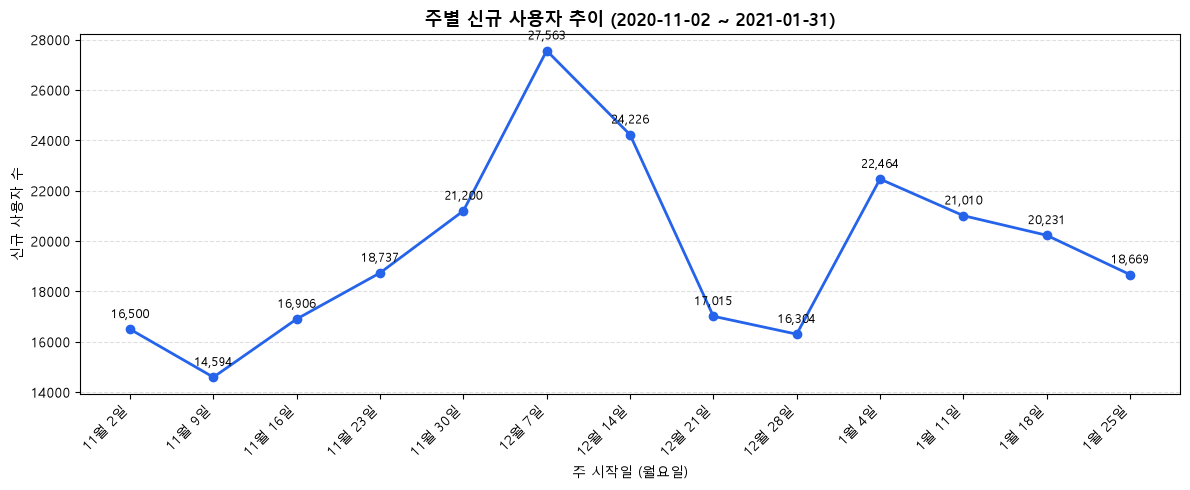

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# 한글 폰트 설정 (Windows 기준, Mac은 'AppleGothic'으로 변경)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# Total Sum 행 제외하고 주별 데이터만 사용
df_weekly = df[df['week_start'] != 'Total Sum'].copy()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_weekly['week_start'], df_weekly['new_users'], marker='o', linewidth=2, color='#2563eb')

# 각 포인트 위에 값 라벨 표시
for x, y in zip(df_weekly['week_start'], df_weekly['new_users']):
    ax.annotate(f'{y:,}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

ax.set_title('주별 신규 사용자 추이 (2020-11-02 ~ 2021-01-31)', fontsize=13, fontweight='bold')
ax.set_xlabel('주 시작일 (월요일)')
ax.set_ylabel('신규 사용자 수')

# x축 눈금을 week_start 값 전부로 명시 지정
ax.set_xticks(df_weekly['week_start'])

# 라벨을 "11월 2일" 형식으로 커스텀 포맷
xtick_labels = [f"{d.month}월 {d.day}일" for d in df_weekly['week_start']]
ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('weekly_new_users.png', dpi=150)
plt.show()

### 구간별 가설과 이후 분석 단계

#### 1) 12/7 주 피크는 특정 채널이 견인했을 것이다

11/23 주(18,737)보다 2주 뒤인 12/7 주가 더 높게 나타난 점은, 단순한 블랙프라이데이 효과라기보다 일정 시차가 있는 다른 원인이 있을 가능성이 있음


#### 2) 12/21~12/28 주 급락은 채널별로 다르게 나타날 것이다

연말 하락이 모든 채널에서 동일하게 나타난다면 계절적 소비 패턴으로 볼 수 있지만, 특정 채널만 급락했다면 광고 예산 소진 또는 집행 중단의 영향일 가능성이 큼.


#### 3) 1/4 주 반등은 신규 캠페인 재개 또는 새해 검색 트래픽 때문일 것이다

12/28 주(16,304) 대비 1/4 주(22,464) 급등은 새해 소비 트렌드 변화 또는 광고 재개 효과를 반영했을 가능성이 있음.


#### 4) 이 변동이 특정 지역에 편중되어 있을 것이다

블랙프라이데이, 크리스마스, 새해는 특정 국가에서 더 강하게 나타날 수 있으므로, 지역별 비중을 확인하면 유입 변동의 원인을 더 정확히 추정할 수 있음.


### 이후 분석 단계

가장 우선적으로 검증해야 할 축은 채널임. 채널이 왜 이런 변동이 발생했는지에 더 직접적으로 설명할 가능성이 높기 때문임.

다음 단계는 주별 × 채널 교차 집계로 넘어가, 각 구간에서 어떤 채널이 변동을 주도했는지 확인하는 것임.

이를 통해 상승/하락 구간의 원인을 보다 명확하게 해석할 수 있음.

---

# 채널별 신규 이용자 유입 분석

## 캠페인별 신규 사용자 집계

이 코드는 `first_visit` 이벤트를 기준으로 캠페인별 신규 사용자 수를 집계함.

- `traffic_source.name`별 유입 건수 비교


In [8]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
WITH campaign AS (
    SELECT
        traffic_source.name AS campaign_name,
        COUNT(*) AS event_cnt
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE event_name = 'first_visit'
        AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
    GROUP BY campaign_name
),
total AS (
    SELECT
        'Total Sum' AS campaign_name,
        COUNT(*) AS event_cnt
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE event_name = 'first_visit'
        AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
)
SELECT * FROM campaign
UNION ALL
SELECT * FROM total
ORDER BY campaign_name = 'Total Sum', event_cnt DESC
"""

df = client.query(query).to_dataframe()
print(df)

    campaign_name  event_cnt
0       (organic)      98074
1        (direct)      60899
2         <Other>      60141
3      (referral)      36367
4  (data deleted)         35
5       Total Sum     255516


## 매체별 신규 사용자 집계

이 코드는 `first_visit` 이벤트를 기준으로 유입 매체별 신규 사용자 수를 집계함.

- `traffic_source.medium`별 유입 건수 비교
- Organic, Paid, Referral, Direct 등 채널별 규모 파악
- 주별 신규 사용자 변동을 설명하는 주요 매체 확인


In [9]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
WITH medium_group AS (
    SELECT
        traffic_source.medium AS medium,
        COUNT(*) AS event_cnt
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE event_name = 'first_visit'
        AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
    GROUP BY medium
),
total AS (
    SELECT
        'Total Sum' AS medium,
        COUNT(*) AS event_cnt
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE event_name = 'first_visit'
        AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
)
SELECT * FROM medium_group
UNION ALL
SELECT * FROM total
ORDER BY medium = 'Total Sum', event_cnt DESC
"""

df = client.query(query).to_dataframe()
print(df)

           medium  event_cnt
0         organic      98074
1          (none)      60899
2         <Other>      46127
3        referral      36367
4             cpc      14013
5  (data deleted)         36
6       Total Sum     255516


## 소스별 신규 사용자 집계

이 코드는 `first_visit` 이벤트를 기준으로 유입 소스별 신규 사용자 수를 집계함.

- `traffic_source.source`별 유입 건수 비교
- 검색엔진, 외부 사이트 등 구체적인 유입 출처 확인
- 동일한 매체 안에서 어떤 소스가 유입을 주도했는지 파악


In [10]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
WITH medium_group AS (
    SELECT
        traffic_source.source AS source,
        COUNT(*) AS event_cnt
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE event_name = 'first_visit'
        AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
    GROUP BY source
),
total AS (
    SELECT
        'Total Sum' AS source,
        COUNT(*) AS event_cnt
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE event_name = 'first_visit'
        AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
)
SELECT * FROM medium_group
UNION ALL
SELECT * FROM total
ORDER BY source = 'Total Sum', event_cnt DESC
"""

df = client.query(query).to_dataframe()
print(df)

                            source  event_cnt
0                           google     103676
1                          <Other>      78250
2                         (direct)      60899
3  shop.googlemerchandisestore.com      12656
4                   (data deleted)         35
5                        Total Sum     255516


## 캠페인, 매체, 소스 조합별 신규 사용자 집계

이 코드는 캠페인명, 매체, 소스를 함께 묶어 유입 조합별 신규 사용자 수를 집계함.

- 세 가지 유입 차원을 동시에 비교
- 각 조합의 실제 유입 규모 확인
- 이후 채널 그룹핑과 캠페인 단위 분석 가능 여부 판단에 활용


In [11]:
from google.cloud import bigquery

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
WITH grouped AS (
    SELECT
        traffic_source.name AS campaign_name,
        traffic_source.medium AS medium,
        traffic_source.source AS source,
        COUNT(*) AS event_cnt
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE event_name = 'first_visit'
        AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
    GROUP BY campaign_name, medium, source
),
total AS (
    SELECT
        'Total Sum' AS campaign_name,
        'Total Sum' AS medium,
        'Total Sum' AS source,
        COUNT(*) AS event_cnt
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE event_name = 'first_visit'
        AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
)
SELECT * FROM grouped
UNION ALL
SELECT * FROM total
ORDER BY campaign_name = 'Total Sum', campaign_name ASC, medium ASC
"""

df = client.query(query).to_dataframe()
print(df)

     campaign_name          medium                           source  event_cnt
0   (data deleted)  (data deleted)                   (data deleted)         34
1   (data deleted)  (data deleted)                          <Other>          1
2         (direct)          (none)                         (direct)      60899
3        (organic)         organic                          <Other>       8412
4        (organic)         organic                           google      89662
5       (referral)        referral  shop.googlemerchandisestore.com      12656
6       (referral)        referral                          <Other>      23711
7          <Other>  (data deleted)                   (data deleted)          1
8          <Other>         <Other>                          <Other>      46126
9          <Other>         <Other>                           google          1
10         <Other>             cpc                           google      14013
11       Total Sum       Total Sum                  


### 각 조합 설명

| # | 조합 | 쉬운 설명 |
|---|---|---|
| 0 | (data deleted) / (data deleted) / (data deleted) | 세 필드 모두 프라이버시 설정으로 정보 삭제 |
| 1 | (data deleted) / (data deleted) / \<Other\> | campaign·medium은 삭제, source만 미분류로 남은 극소수 예외 |
| 2 | (direct) / (none) / (direct) | 주소창 직접 입력, 북마크, 카톡·문자 링크 — 추적 신호(리퍼럴 정보) 자체가 없음 |
| 3 | (organic) / organic / \<Other\> | 구글이 아닌 다른 검색엔진(네이버, 빙 등)으로 자연 유입 |
| 4 | (organic) / organic / google | 구글 검색 결과(광고 아님)를 클릭해서 들어옴 — 가장 흔한 유입 |
| 5 | (referral) / referral / \<Other\> | 외부 사이트(블로그·커뮤니티 등) 링크 클릭, 출처는 불명 |
| 6 | (referral) / referral / shop.googlemerchandisestore.com | 사이트 내부 이동인데 리퍼럴로 잘못 잡힌 경우. source가 외부 도메인이 아닌 자기 자신이라 "제3자 소개"라는 referral의 정의를 충족하지 못함 → 제3자 개입 없이 온 Direct의 정의에 더 부합 |
| 7 | \<Other\> / (data deleted) / (data deleted) | name은 미분류, medium·source는 삭제된 극소수 예외 |
| 8 | \<Other\> / \<Other\> / google | 구글에서 온 건 확실하나 방식(medium)은 미분류인 극소수 예외 |
| 9 | \<Other\> / \<Other\> / \<Other\> | 어디서 왔는지 신호는 있으나 GA4가 못 알아본 미분류 유입 (앱 인앱브라우저 등) |
| 10 | \<Other\> / cpc / google | 구글 유료 검색 광고 클릭 (캠페인명이 안 붙어서 \<Other\>) |

### 그룹핑 과정

세부 source는 다르지만 **유입 "방식"(medium) 이 같으면 하나의 채널로 묶는 게 분석에 유리**함.

- **Organic Search**: #3 + #4 → medium=organic 기준으로 통합 (구글이든 아니든 "자연 검색"이라는 본질은 동일)
- **Direct**: #2 + #6 → #6(자사 도메인 셀프 리퍼럴)은 source가 외부가 아닌 자기 자신이라 "제3자 소개" 조건을 충족하지 못하므로, 정의상 Referral이 아닌 Direct로 재분류
- **Paid Search**: #10 단독 (campaign_name이 \<Other\>여도 medium=cpc면 명확히 유료광고)
- **Referral**: #5 단독 (실제 외부 도메인 미상이지만 제3자 개입은 확인됨)
- **Unassigned**: #0, #1, #7, #8, #9 → 전부 합쳐서 "채널 특정 불가"로 처리 (총 46,163건)

**결론: 그룹핑은 `medium` 기준을 기본으로 하되, `source`가 자사 도메인인 경우(#6)만 예외적으로 `source`까지 함께 확인해 Direct로 재분류함.**

### 데이터 상 한계 — 캠페인 단위 분석 불가

- `campaign_name`에 실제 마케팅 캠페인명(예: "2020_black_friday_sale")이 단 한 건도 없고, 전부 GA4 자동 placeholder(`(organic)`, `(direct)`, `<Other>`, `(referral)`, `(data deleted)`)로만 구성됨
- 이는 UTM `utm_campaign` 파라미터가 붙은 유입이 이 데이터셋에 존재하지 않는다는 의미
- 따라서 **"어떤 캠페인이 신규 유입을 얼마나 데려왔는가"와 같은 캠페인 단위 성과 분석은 불가능**
- 대신 `medium`/`source`는 UTM 없이도 브라우저 리퍼러로 자동 판별되므로, **채널(Organic/Direct/Paid/Referral) 단위 분석으로 범위를 한정**하여 진행

In [12]:
from google.cloud import bigquery
import matplotlib.pyplot as plt

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
WITH first_visit_users AS (
  SELECT
    user_pseudo_id,
    traffic_source.source AS source,
    traffic_source.medium AS medium
  FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
  WHERE event_name = 'first_visit'
    AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
),

channel_grouped AS (
  SELECT
    user_pseudo_id,
    CASE
      WHEN medium = 'organic' THEN 'Organic Search'
      WHEN medium = 'cpc' THEN 'Paid Search'
      WHEN medium = '(none)' AND source = '(direct)' THEN 'Direct'
      WHEN medium = 'referral' AND source = 'shop.googlemerchandisestore.com' THEN 'Direct'
      WHEN medium = 'referral' THEN 'Referral'
      ELSE 'Unassigned'
    END AS channel_group
  FROM first_visit_users
),

channel_summary AS (
  SELECT
    channel_group,
    COUNT(*) AS user_cnt,
    ROUND(COUNT(*) / SUM(COUNT(*)) OVER() * 100, 1) AS pct
  FROM channel_grouped
  GROUP BY channel_group
),

total AS (
  SELECT
    'Total Sum' AS channel_group,
    SUM(user_cnt) AS user_cnt,
    100.0 AS pct
  FROM channel_summary
)

SELECT * FROM channel_summary
UNION ALL
SELECT * FROM total
ORDER BY channel_group = 'Total Sum', user_cnt DESC
"""

df_channel = client.query(query).to_dataframe()
df_channel

,channel_group,user_cnt,pct
0,Organic Search,98074,38.4
1,Direct,73555,28.8
2,Unassigned,46163,18.1
3,Referral,23711,9.3
4,Paid Search,14013,5.5
5,Total Sum,255516,100.0


### 채널별 신규 이용자 비율 
- GA4의 `first_visit` 이벤트를 조회해 전체 신규 이용자를 추출함.
- 그룹핑 규칙을 기반으로 전체 신규 이용자에 대한 비율 계산

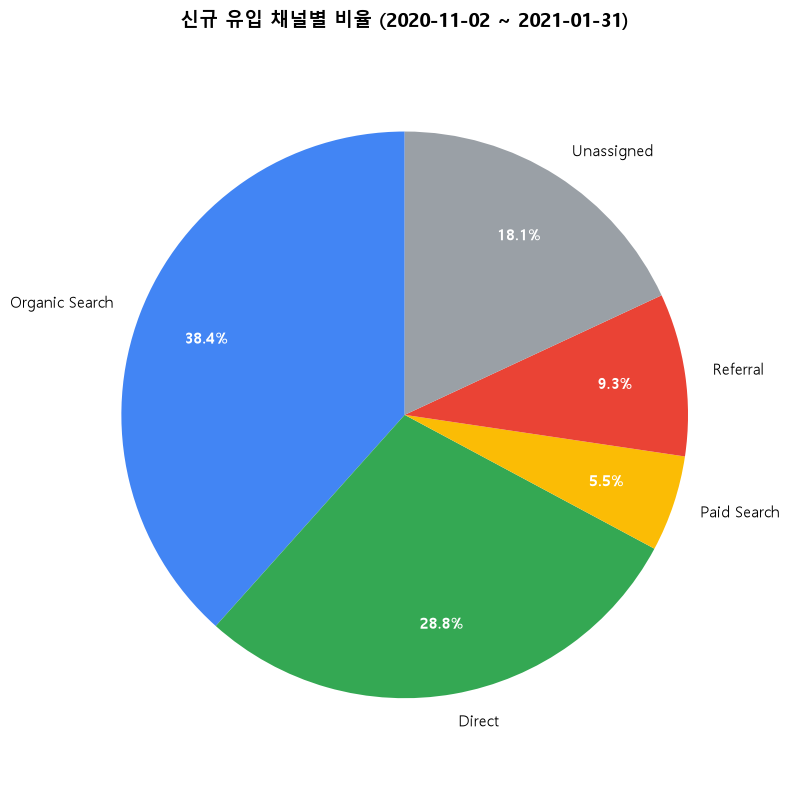

    channel_group  user_cnt   pct
0  Organic Search     98074  38.4
1          Direct     73555  28.8
2     Paid Search     14013   5.5
3        Referral     23711   9.3
4      Unassigned     46163  18.1


In [13]:
# ============================================
# 파이 차트 시각화
# ============================================

# 채널 순서/색상 고정 (일관된 시각화를 위해)
channel_order = ['Organic Search', 'Direct', 'Paid Search', 'Referral', 'Unassigned']
df_channel_sorted = df_channel.set_index('channel_group').reindex(channel_order).reset_index()

colors = ['#4285F4', '#34A853', '#FBBC05', '#EA4335', '#9AA0A6']  # Google 팔레트 + 회색(Unassigned)

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    df_channel_sorted['user_cnt'],
    labels=df_channel_sorted['channel_group'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.75,
    textprops={'fontsize': 11}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('신규 유입 채널별 비율 (2020-11-02 ~ 2021-01-31)', fontsize=14, fontweight='bold', pad=20)
ax.axis('equal')

plt.tight_layout()
plt.savefig('channel_distribution_pie.png', dpi=150, bbox_inches='tight')
plt.show()

print(df_channel_sorted)

In [14]:
from google.cloud import bigquery
import matplotlib.pyplot as plt
import pandas as pd

client = bigquery.Client(project="pro-talon-503713-s3")

# ============================================
# 주별 x 채널별 신규 사용자 집계
# ============================================
query = """
WITH first_visit_users AS (
  SELECT
    user_pseudo_id,
    DATE_TRUNC(PARSE_DATE('%Y%m%d', event_date), WEEK(MONDAY)) AS week_start,
    traffic_source.source AS source,
    traffic_source.medium AS medium
  FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
  WHERE event_name = 'first_visit'
    AND _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
),

channel_grouped AS (
  SELECT
    user_pseudo_id,
    week_start,
    CASE
      WHEN medium = 'organic' THEN 'Organic Search'
      WHEN medium = 'cpc' THEN 'Paid Search'
      WHEN medium = '(none)' AND source = '(direct)' THEN 'Direct'
      WHEN medium = 'referral' AND source = 'shop.googlemerchandisestore.com' THEN 'Direct'
      WHEN medium = 'referral' THEN 'Referral'
      ELSE 'Unassigned'
    END AS channel_group
  FROM first_visit_users
)

SELECT
  week_start,
  channel_group,
  COUNT(*) AS user_cnt
FROM channel_grouped
GROUP BY week_start, channel_group
ORDER BY week_start, channel_group
"""

df_weekly_channel = client.query(query).to_dataframe()
df_weekly_channel

,week_start,channel_group,user_cnt
0,2020-11-02,Direct,4702
1,2020-11-02,Organic Search,6357
2,2020-11-02,Paid Search,947
3,2020-11-02,Referral,1532
4,2020-11-02,Unassigned,2972
...,...,...,...
60,2021-01-25,Direct,5399
61,2021-01-25,Organic Search,7180
62,2021-01-25,Paid Search,1046
63,2021-01-25,Referral,1684


In [15]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="pro-talon-503713-s3")

query = """
SELECT
    DATE_TRUNC(PARSE_DATE('%Y%m%d', event_date), WEEK(MONDAY)) AS week_start,
    CASE
        WHEN traffic_source.source = 'shop.googlemerchandisestore.com'
            AND traffic_source.medium = 'referral' THEN 'Direct'
        WHEN traffic_source.medium = '(none)'
            AND traffic_source.source = '(direct)' THEN 'Direct'
        WHEN traffic_source.medium = 'organic' THEN 'Organic Search'
        WHEN traffic_source.medium IN ('cpc', 'ppc', 'paidsearch') THEN 'Paid Search'
        WHEN traffic_source.medium = 'referral' THEN 'Referral'
        ELSE 'Unassigned'
    END AS channel,
    COUNT(*) AS new_users
FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
WHERE _TABLE_SUFFIX BETWEEN '20201102' AND '20210131'
    AND event_name = 'first_visit'
GROUP BY week_start, channel
ORDER BY week_start, channel
"""

df_weekly_channel = client.query(query).to_dataframe()

# 피벗: 행=주차, 열=채널, 값=신규 유저 수
df_pivot = df_weekly_channel.pivot_table(
    index='week_start',
    columns='channel',
    values='new_users',
    aggfunc='sum',
    fill_value=0
)

# 5개 채널이 모두 컬럼으로 존재하도록 보정 (특정 주차에 값이 0인 채널이 있으면 컬럼 자체가 누락될 수 있음)
channel_order = ['Organic Search', 'Direct', 'Paid Search', 'Referral', 'Unassigned']
df_pivot = df_pivot.reindex(columns=channel_order, fill_value=0)

print(df_pivot)

channel     Organic Search  Direct  Paid Search  Referral  Unassigned
week_start                                                           
2020-11-02            6357    4702          947      1532        2972
2020-11-09            5571    4182          814      1327        2706
2020-11-16            6506    4942          900      1564        3002
2020-11-23            7204    5371          983      1751        3434
2020-11-30            8211    6095         1250      1903        3750
2020-12-07           10520    7885         1533      2601        5030
2020-12-14            9218    7070         1345      2263        4340
2020-12-21            6590    4768          921      1623        3118
2020-12-28            6256    4711          857      1551        2936
2021-01-04            8768    6467         1207      2006        4025
2021-01-11            8028    6110         1084      2019        3781
2021-01-18            7665    5853         1126      1887        3704
2021-01-25          

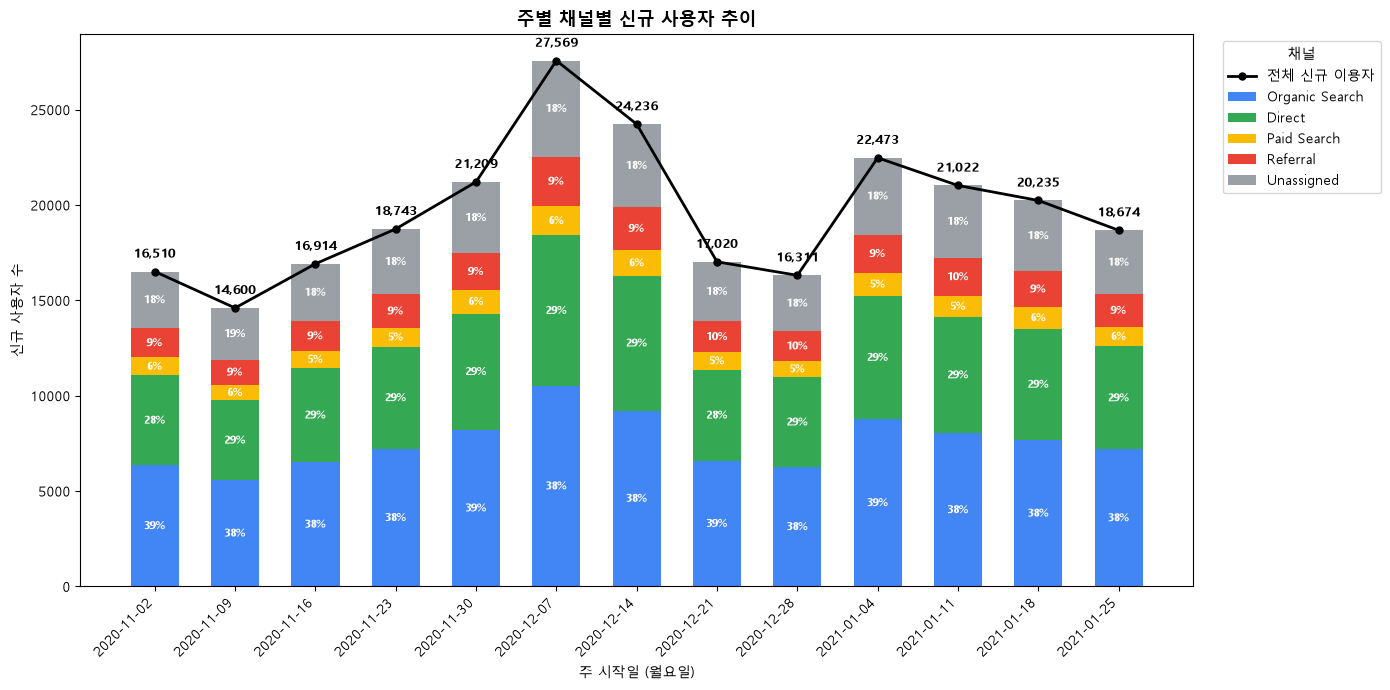

In [16]:
# ============================================
# 주별 채널별 누적 막대 그래프 + 구간별 비율(%) 라벨 + 전체 신규 이용자 라인 그래프
# ============================================

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

channel_order = ['Organic Search', 'Direct', 'Paid Search', 'Referral', 'Unassigned']
colors = {
    'Organic Search': '#4285F4',
    'Direct': '#34A853',
    'Paid Search': '#FBBC05',
    'Referral': '#EA4335',
    'Unassigned': '#9AA0A6'
}

# 주별 총 신규 이용자 수 (라인 그래프용)
weekly_total = df_pivot.sum(axis=1)

# 주별 x 채널별 비율(%) - 라벨 표시용
df_pivot_pct = df_pivot.div(weekly_total, axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))

x_labels = df_pivot.index.astype(str)
bottom = pd.Series([0] * len(df_pivot), index=df_pivot.index)

for channel in channel_order:
    bars = ax.bar(
        x_labels,
        df_pivot[channel],
        bottom=bottom,
        label=channel,
        color=colors[channel],
        width=0.6
    )

    # 각 구간 중앙에 비율(%) 라벨 표시 (구간이 너무 작으면 생략)
    for i, (week, value) in enumerate(df_pivot[channel].items()):
        pct = df_pivot_pct.loc[week, channel]
        if value > 0 and pct >= 4:  # 너무 작은 구간엔 라벨 생략 (겹침 방지)
            y_pos = bottom[week] + value / 2
            ax.text(
                i, y_pos, f'{pct:.0f}%',
                ha='center', va='center',
                fontsize=8, color='white', fontweight='bold'
            )

    bottom += df_pivot[channel]

# 전체 신규 이용자 수 라인 그래프 (같은 y축, 누적 막대 상단과 동일선상)
ax.plot(
    x_labels, weekly_total,
    color='black', marker='o', linewidth=2, markersize=5,
    label='전체 신규 이용자', zorder=5
)

for i, (week, total) in enumerate(weekly_total.items()):
    ax.annotate(
        f'{total:,}', (i, total),
        textcoords='offset points', xytext=(0, 10),
        ha='center', fontsize=9, fontweight='bold'
    )

ax.set_title('주별 채널별 신규 사용자 추이', fontsize=13, fontweight='bold')
ax.set_xlabel('주 시작일 (월요일)')
ax.set_ylabel('신규 사용자 수')
ax.legend(title='채널', loc='upper left', bbox_to_anchor=(1.02, 1.0))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('weekly_channel_stacked_bar_with_pct_and_line.png', dpi=150, bbox_inches='tight')
plt.show()

### 채널별 비율 변동폭

아래 표는 2020-11-02부터 2021-01-25까지 주별 채널 비율의 최솟값과 최댓값을 비교한 내용입니다.

| 채널 | 최솟값 | 최댓값 | 변동폭 | 간단한 해석 |
|---|---:|---:|---:|---|
| Organic Search | 38% | 39% | 1%p | 가장 큰 비중을 유지하며 변동이 작음 |
| Direct | 28% | 29% | 1%p | 두 번째로 큰 비중을 안정적으로 유지함 |
| Paid Search | 5% | 6% | 1%p | 전체 비중은 작지만 주별로 소폭 변동함 |
| Referral | 9% | 10% | 1%p | 대부분 9% 수준이며 일부 주에 10%로 증가함 |
| Unassigned | 18% | 19% | 1%p | 대체로 18% 수준으로 유지되며 일부 주에만 상승함 |

### 결론

**신규 이용자 수의 주별 증감은 채널 구성 변화가 아니라 전체 트래픽 자체의 변동에서 비롯된 것으로 보임.**

- 13주 전 구간에서 5개 채널(Organic Search, Direct, Paid Search, Referral, Unassigned)의 비율이 모두 ±1%p 이내로 거의 고정되어 있었음.
- 신규 이용자가 최저치인 14,600명(11/9 주)에서 최고치인 27,569명(12/7 주)까지 변동하는 동안에도 채널 구성비는 거의 동일하게 유지됨.
- 특정 채널의 광고 집행 또는 중단보다는 모든 채널에 공통으로 영향을 미치는 계절성이나 시즌 이벤트 등이 원인일 가능성을 시사함.

### 가설 검증 결과

- **“12/7 주 피크는 특정 채널이 견인했을 것이다”**: 채널별 비율 변동폭이 1%p 이내로 작아 **기각**됨.
- **“12/21~12/28 급락은 채널별로 다르게 나타날 것이다”**: 채널 구성비가 거의 일정하게 유지되어 **기각**됨.

따라서 해당 기간의 신규 이용자 증감은 특정 채널의 구성 변화보다 전체 유입 규모의 변화로 설명하는 것이 타당함.

### A(고객 유치) 단계 — 데이터 한계로 분석 불가능한 항목

이 데이터셋은 아래 항목들에 대한 원천 데이터가 없어, 실무적으로 중요함에도 분석이 불가능함.

#### 1. CAC (고객획득비용)
- **왜 중요한가**: 채널별로 "얼마나 효율적으로" 신규 유저를 데려왔는지 판단하는 핵심 지표. 유입량이 많아도 비용이 비싸면 비효율적인 채널일 수 있음.
- **왜 불가능한가**: 광고비/캠페인 예산 데이터가 데이터셋에 전혀 포함되어 있지 않음.

#### 2. 캠페인 단위 성과 분석
- **왜 중요한가**: "어떤 캠페인이 신규 유입에 얼마나 견인했는가" — 마케팅 예산 재배분 의사결정에 직결되는 실무 핵심 분석
- **왜 불가능한가**: `campaign_name`에 실제 UTM 캠페인명이 단 1건도 없고, 전부 GA4 자동 입력 값(`(organic)`, `(direct)`, `<Other>` 등)으로만 구성됨.

#### 3. Social 채널 유입
- **왜 중요한가**: 이커머스에서도 인스타/페이스북 광고, 인플루언서 마케팅을 통한 유입은 일반적으로 중요한 채널 중 하나
- **왜 불가능한가**: `medium` 고윳값에 social 관련 값이 이 데이터셋(기간) 안에 아예 존재하지 않음

#### 4. Unassigned(18.1%)의 실제 유입 경로
- **왜 중요한가**: 신규 유저 5명 중 1명 가까이가 "어디서 왔는지" 특정이 안 됨 — 이 비중이 크면 채널 전략 수립 자체의 신뢰도가 떨어짐
- **왜 불가능한가**: `traffic_source` 신호 자체가 GA4 내부적으로 미분류 처리되어, 원인이 되는 데이터가 없어 역추적이 불가능함

---

# 디바이스별 신규 이용자 유입 분석

### 그룹별 신규 이용자 집계 함수 정의
GA4 이벤트 테이블에서 지정한 컬럼을 기준으로 고윳값과 그 수를 집계하고, 기간과 이벤트 조건을 적용한 뒤 전체 합계 행까지 추가하는 공통 함수를 정의함.

In [20]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="pro-talon-503713-s3")

def get_grouped_counts(
    group_col,
    event_name=None,
    start_date="20201102",
    end_date="20210131",
    label="Total"
):
    """
    GA4 이벤트 테이블에서 group_col 기준으로 고윳값별 카운트를 집계하고
    마지막에 합계 행을 추가해서 반환.

    Parameters
    ----------
    group_col : str
        GROUP BY에 사용할 컬럼 (예: "device.category AS device_category")
    event_name : str or None
        특정 이벤트만 필터링할 경우 이벤트명 (예: "first_visit")
    start_date, end_date : str
        _TABLE_SUFFIX 범위 (YYYYMMDD)
    label : str
        합계 행에 표시할 라벨
    """
    # group_col에 AS가 있으면 별칭만 추출, 없으면 그대로 사용
    alias = group_col.split(" AS ")[-1].strip() if " AS " in group_col else group_col

    where_clause = f"_TABLE_SUFFIX BETWEEN '{start_date}' AND '{end_date}'"
    if event_name:
        where_clause += f"\n    AND event_name = '{event_name}'"

    query = f"""
    SELECT
        {group_col},
        COUNT(*) AS user_count
    FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
    WHERE {where_clause}
    GROUP BY {alias}
    ORDER BY user_count DESC
    """

    df = client.query(query).to_dataframe()

    # 합계 행 추가
    total = {}
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            total[col] = df[col].sum()
        elif col == alias:
            total[col] = label
        else:
            total[col] = ""
    df = pd.concat([df, pd.DataFrame([total])], ignore_index=True)

    return df

### 디바이스 카테고리별 신규 이용자 집계
앞에서 정의한 함수를 사용해 `first_visit` 이벤트가 발생한 신규 이용자를 디바이스 카테고리별로 집계하고 결과를 출력함.

In [23]:
df_device = get_grouped_counts("device.category", event_name="first_visit")
print(df_device)

  category  user_count
0  desktop      148420
1   mobile      101345
2   tablet        5751
3               255516
